# 02 · Perfilado, limpieza y validación de calidad

Objetivo: pasar de staging (datos "como vienen") a **tablas limpias y confiables**, dejando evidencia de **cada** decisión.

- `sql/02_profiling.sql` → mide los problemas (cada consulta queda guardada en `data/processed/evidencia/`)
- `sql/03_clean.sql` → aplica las reglas y valida el resultado
- `sql/04_marts.sql` → series agregadas para el análisis
- Resumen de decisiones: `reports/01_calidad_datos.md`

> Regla del proyecto: ninguna fila se descarta en silencio. Todo filtro tiene un conteo y una justificación.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import config
import viz
from formato import fmt_cantidad, fmt_hogares, fmt_mes, fmt_monto, fmt_pct, fmt_decimal
from run_sql import run_file

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)

In [2]:
import os
os.chdir(config.ROOT)
con = duckdb.connect(str(config.DB_PATH))
run_file(con, config.ROOT / "sql" / "02_profiling.sql")


=== 02_profiling.sql

-- eph_hogares_por_trimestre (4 filas)
   anio trimestre  hogares  hogares_expandidos_pondera  hogares_expandidos_pondih
0  2025         2    16169               10,126,176.00              10,126,162.00
1  2025         3    15860               10,229,446.00              10,229,502.00
2  2025         4    15534               10,161,212.00              10,161,165.00
3  2026         1    15447               10,207,750.00              10,207,758.00

-- eph_duplicados_clave_trimestre (1 filas)
   filas  claves_distintas  duplicados
0  63010             63010           0

-- eph_panel_repeticiones (2 filas)
   trimestres_en_que_aparece  hogares_distintos   pct
0                          1              17628 43.70
1                          2              22691 56.30

-- eph_tenencia_codigos (10 filas)
  codigo                          descripcion  hogares
0      0           ⚠ código inválido/sin dato       33
1      1       Propietario vivienda y terreno    40956
2    


-- eph_consistencia_itf_vs_suma_individual (2 filas)
               resultado  hogares
0  ITF = suma individual    47517
1     Hogar no respuesta    15493

-- bcra_cobertura_series (13 filas)
                                  serie id_variable  observaciones       desde       hasta  fechas_duplicadas  valores_no_numericos  fechas_futuras
0             hipotecarios_compra_nueva        1115            318  2000-01-31  2026-06-30                  0                  0.00            0.00
1             hipotecarios_compra_usada        1116            318  2000-01-31  2026-06-30                  0                  0.00            0.00
2             hipotecarios_construccion        1113            318  2000-01-31  2026-06-30                  0                  0.00            0.00
3           hipotecarios_otros_destinos        1117            318  2000-01-31  2026-06-30                  0                  0.00            0.00
4                hipotecarios_refaccion        1114            318 


-- gcba_percentiles_m2_usdm2 (20 filas)
    anio                                           m2_p01_1_50_99_999                                       usd_m2_p01_1_50_99_999  m2_menor_15  m2_mayor_500  usd_m2_menor_300  usd_m2_mayor_15000
0   2001                 [22.0, 30.0, 72.0, 250.0, 370.4500000000007]  [254.4363636363636, 393.8116197183098, 872.0930232558139...         0.00          1.00             33.00                0.00
1   2002                 [21.0, 27.0, 70.0, 260.0, 396.3799999999992]  [77.82067773550098, 154.87120870629147, 471.153846153846...         0.00          3.00            928.00                0.00
2   2003   [21.0, 27.0, 70.0, 245.76000000000022, 417.38000000000284]  [137.85275462962963, 214.4126984126984, 571.428571428571...         0.00          5.00            610.00                0.00
3   2004                [35.0, 41.0, 67.0, 160.0, 215.96500000000106]  [161.92970588235295, 305.5952380952381, 773.333333333333...         0.00          0.00             45.00

In [3]:
EV = config.PROCESSED / "evidencia"
def ev(carpeta, nombre):
    return pd.read_csv(EV / carpeta / f"{nombre}.csv")

## 1. EPH: problemas encontrados

### 1.1 El panel rotativo repite hogares
La EPH entrevista a cada vivienda 2 trimestres, la deja 2 y vuelve 2. Al juntar 4 trimestres, **más de la mitad de los hogares aparece dos veces**.

> **Decisión y corrección (Checkpoint 3).** La primera versión se quedaba con la visita más reciente de cada hogar. Al revisar la cantidad de inquilinos contra el Censo 2022 apareció un sesgo: los inquilinos se mudan más, aparecen una sola vez con más frecuencia y quedaban sobrerrepresentados. Se cambió a un **pool**: se apilan los 4 trimestres (cada uno es una muestra representativa) y cada peso se divide por 4. Los márgenes de error tratan las visitas de un mismo hogar como un conglomerado.

In [4]:
ev("02_profiling", "eph_panel_repeticiones")

,trimestres_en_que_aparece,hogares_distintos,pct
0,1,17628,43.70
1,2,22691,56.30


### 1.2 No respuesta de ingresos y códigos inválidos

In [5]:
display(ev("02_profiling", "eph_no_respuesta_ingresos")); display(ev("02_profiling", "eph_tenencia_codigos"))

,situacion,hogares,pct,con_itf_cero,con_pondih_cero
0,Con ingreso declarado (deciles 1-10),47192,74.90,0.00,0.00
1,No respuesta (decil 12),15493,24.60,"15,493.00","15,493.00"
2,Sin ingresos (decil 0),325,0.50,325.00,0.00


,codigo,descripcion,hogares
0,0,⚠ código inválido/sin dato,33
1,1,Propietario vivienda y terreno,40956
2,2,Propietario solo vivienda,3274
3,3,Inquilino,12114
4,4,Ocupante por impuestos/expensas,1586
5,5,Ocupante en relación de dependencia,134
6,6,Ocupante gratuito,3876
7,7,Ocupante de hecho,143
8,8,En sucesión,780
9,9,Otra situación,114


### 1.3 Integridad y consistencia (lo que *está bien* también se documenta)

In [6]:
display(ev("02_profiling", "eph_jefes_por_hogar")); display(ev("02_profiling", "eph_integridad_hogar_individuo")); display(ev("02_profiling", "eph_consistencia_itf_vs_suma_individual")); display(ev("02_profiling", "eph_formalidad_asalariados"))

,cantidad_jefes,hogares
0,1.00,63010


,hogares_sin_individuos,individuos_sin_hogar
0,0,0


,resultado,hogares
0,ITF = suma individual,47517
1,Hogar no respuesta,15493


,pp07h,asalariados_ocupados,pct
0,Con descuento jubilatorio (formal),35816,62.80
1,Sin descuento jubilatorio (informal),21247,37.20


## 2. BCRA y salarios
Las series del BCRA vienen completas (sin huecos ni duplicados). Dos detalles:
- **La API publica la UVA con fechas futuras** (se calcula con el CER anticipado): la descarga filtra a la fecha de corte.
- **Destino del crédito (series 1113-1117):** la API rotula los saldos "en miles de pesos", pero las magnitudes corresponden a millones (se contrastó con el stock total de la serie 916). Se usan como millones y se deja la aclaración en el SQL.

In [7]:
display(ev("02_profiling", "bcra_cobertura_series")); display(ev("02_profiling", "bcra_huecos_mensuales")); display(ev("02_profiling", "salarios_cobertura"))

,serie,id_variable,observaciones,desde,hasta,fechas_duplicadas,valores_no_numericos,fechas_futuras
0,hipotecarios_compra_nueva,1115,318,2000-01-31,2026-06-30,0,0.00,0.00
1,hipotecarios_compra_usada,1116,318,2000-01-31,2026-06-30,0,0.00,0.00
2,hipotecarios_construccion,1113,318,2000-01-31,2026-06-30,0,0.00,0.00
3,hipotecarios_otros_destinos,1117,318,2000-01-31,2026-06-30,0,0.00,0.00
4,hipotecarios_refaccion,1114,318,2000-01-31,2026-06-30,0,0.00,0.00
5,inflacion_interanual,28,320,2000-01-31,2026-08-31,0,0.00,0.00
6,inflacion_mensual,27,320,2000-01-31,2026-08-31,0,0.00,0.00
7,stock_hipotecarios_personas_humanas,916,318,2000-01-31,2026-06-30,0,0.00,0.00
8,tasa_hipotecaria_fija,1217,320,2000-01-31,2026-08-31,0,0.00,0.00
9,tasa_hipotecaria_uva,1240,124,2016-05-31,2026-08-31,0,0.00,0.00


,serie,desde,hasta,meses_con_dato,meses_esperados,meses_faltantes
0,inflacion_interanual,2000-01-01,2026-08-01,320,320,0
1,inflacion_mensual,2000-01-01,2026-08-01,320,320,0
2,stock_hipotecarios_personas_humanas,2000-01-01,2026-06-01,318,318,0
3,tasa_hipotecaria_fija,2000-01-01,2026-08-01,320,320,0
4,tasa_hipotecaria_uva,2016-05-01,2026-08-01,124,124,0


,desde,hasta,meses,total_nulos,total_desde,registrado_nulos
0,2015-10-01,2026-06-01,129,12.00,2016-10-01,0.00


## 3. GCBA avisos: el dataset más sucio

### 3.1 Duplicados: en algunos años, más de la mitad de las filas

In [8]:
ev("02_profiling", "gcba_duplicados_por_anio").set_index("anio").T

anio,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
avisos,"12,911.00","7,363.00","13,525.00","4,808.00","3,503.00","3,448.00","7,910.00","7,524.00","23,614.00","18,466.00","17,314.00","8,828.00","17,576.00","12,724.00","11,414.00","7,564.00","72,124.00","84,813.00","88,640.00","156,258.00"
duplicados,173.00,70.00,189.00,12.00,5.00,8.00,26.00,238.00,379.00,18.00,0.00,1.00,17.00,43.00,14.00,"2,518.00","41,908.00","6,582.00","13,002.00","74,835.00"
pct_duplicados,1.30,1.00,1.40,0.20,0.10,0.20,0.30,3.20,1.60,0.10,0.00,0.00,0.10,0.30,0.10,33.30,58.10,7.80,14.70,47.90


### 3.2 Variantes de escritura de barrios (caracteres rotos, truncados, sub-barrios)

In [9]:
b = ev("02_profiling", "gcba_barrios_variantes")
b[b.barrio_tal_cual.fillna("").str.contains("NU|MONSERRAT|MONTSERRAT|MITR|AVELLANED|ESTE|OESTE|NORTE|SUR", regex=True) | b.barrio_tal_cual.isna()]

,barrio_tal_cual,avisos,primer_anio,ultimo_anio
4,BARRACAS ESTE,3126,2019,2020
5,BARRACAS OESTE,5,2019,2020
15,FLORES NORTE,8772,2019,2020
16,FLORES SUR,1095,2019,2020
20,MONSERRAT,1693,2001,2016
22,MONTSERRAT,8556,2007,2020
23,NU?ÆEZ,2533,2020,2020
24,NUEVA POMPEYA,1277,2001,2020
25,NUNEZ,1203,2009,2013
26,NUÃ‘EZ,348,2019,2019


### 3.3 Coordenadas invertidas o inválidas y USD/m² inconsistente

In [10]:
display(ev("02_profiling", "gcba_coordenadas_invalidas").set_index("anio").T); display(ev("02_profiling", "gcba_usd_m2_inconsistente").set_index("anio").T)

anio,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
lat_lon_invertidas,"12,911.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,NaN
fuera_de_rango,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,150.00,0.00,0.00,0.00,0.00,0.00,0.00,"9,167.00",0.00
sin_coordenadas,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,621.00,"1,382.00","72,124.00",0.00,0.00,"156,258.00"


anio,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
con_ambos_valores,"12,911.00","7,363.00","13,525.00","4,808.00","3,503.00","3,448.00","7,905.00","7,429.00","23,614.00","18,466.00","17,314.00","8,828.00","17,576.00","12,724.00","11,414.00","7,563.00","72,121.00","84,187.00","86,721.00","156,258.00"
difieren_mas_5pct,0.00,0.00,0.00,0.00,0.00,0.00,0.00,37.00,8.00,0.00,1.00,1.00,0.00,4.00,0.00,"4,877.00","45,360.00","34,966.00","48,193.00","22,085.00"


> **Diagnóstico del USD/m² inconsistente (2016-2020):** el valor publicado se calculó sobre **m² cubiertos** y en 2001-2015 sobre **m² totales**. No es un error de carga sino un cambio de definición → se **recalcula** precio / m² total en todos los años para que la serie sea comparable.

## 4. Aplicar la limpieza

In [11]:
run_file(con, config.ROOT / "sql" / "03_clean.sql")
run_file(con, config.ROOT / "sql" / "04_marts.sql")


=== 03_clean.sql


  ok: ﻿-- =====================================================================
  ok: CREATE OR REPLACE TABLE series_mensuales AS
  ok: DROP TABLE int_series_base;


  ok: CREATE OR REPLACE TABLE hogares_eph AS
  ok: CREATE OR REPLACE TABLE ref_barrios_caba AS


  ok: CREATE OR REPLACE TABLE int_gcba_base AS


  ok: CREATE OR REPLACE TABLE int_gcba_flags AS


  ok: CREATE OR REPLACE TABLE avisos_caba AS
  ok: CREATE OR REPLACE TABLE ref_precios_gba_partido AS
  ok: CREATE OR REPLACE TABLE ref_precios_mercado AS

-- validacion_precios_gba (4 filas)
    corredor  partidos  partidos_sin_precio_propio  hogares_inquilinos_censo  pct_de_inquilinos_gba  usd_m2_ponderado_inquilinos  usd_m2_min  usd_m2_max
0      Norte        10                        0.00                228,046.00                  32.20                     2,125.00    1,065.00    3,025.00
1      Oeste         9                        2.00                245,761.00                  34.70                     1,506.00    1,215.00    2,084.00
2        Sur        12                        3.00                233,695.00                  33.00                     1,733.00    1,444.00    1,984.00
3  Total GBA        31                        5.00                707,502.00                 100.00                     1,781.00    1,065.00    3,025.00

-- validacion_partidos_sin_match (0 filas)

  ok: CREATE OR REPLACE TABLE mart_stress_uva_salarios AS

-- stress_resumen_ventanas (3 filas)
   horizonte_meses  ventanas  peor_cuota_ingreso_pct inicio_peor_ventana  mejor_cuota_ingreso_pct inicio_mejor_ventana  pct_ventanas_sobre_30
0               12       112                   32.20             2023-09                    22.40              2022-09                   6.30
1               24       100                   32.90             2023-09                    21.30              2021-09                  11.00
2               36        88                   31.30             2023-05                    20.80              2020-09                  12.50

-- stress_episodios (13 filas)
     inicio  meses_transcurridos  cuota_ingreso_pct
0   2018-05                    0              25.00
1   2018-05                    6              26.40
2   2018-05                   12              27.60
3   2018-05                   18              28.20
4   2018-05                   24            

### 4.1 Embudo de limpieza GCBA: cuánto saca cada regla

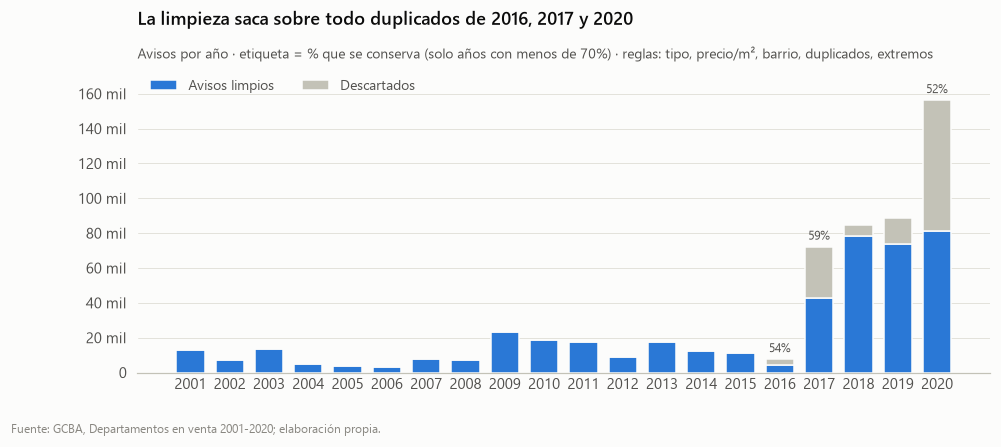

,anio,avisos_crudos,r1_no_venta_depto,r2_precio_m2_invalido,r3_barrio_invalido,r4_duplicados,r5_outliers,avisos_limpios,pct_conservado
0,2001,12911,0.00,1.00,0.00,173.00,74.00,"12,663.00",98.10
1,2002,7363,0.00,3.00,0.00,70.00,8.00,"7,282.00",98.90
2,2003,13525,0.00,5.00,0.00,188.00,4.00,"13,328.00",98.50
3,2004,4808,0.00,0.00,0.00,12.00,8.00,"4,788.00",99.60
4,2005,3503,0.00,0.00,0.00,5.00,2.00,"3,496.00",99.80
5,2006,3448,0.00,5.00,0.00,8.00,7.00,"3,428.00",99.40
6,2007,7910,0.00,10.00,0.00,22.00,6.00,"7,872.00",99.50
7,2008,7524,0.00,126.00,0.00,238.00,10.00,"7,150.00",95.00
8,2009,23614,0.00,26.00,0.00,378.00,35.00,"23,175.00",98.10
9,2010,18466,0.00,10.00,0.00,17.00,20.00,"18,419.00",99.70


In [12]:
emb = ev("03_clean", "gcba_embudo_limpieza")
fig, ax = plt.subplots(figsize=(10, 3.6))
x = emb.anio.astype(str)
descartados = emb.avisos_crudos - emb.avisos_limpios
ax.bar(x, emb.avisos_limpios, color=viz.BLUE, width=0.72, label="Avisos limpios", edgecolor=viz.SURFACE, linewidth=1)
ax.bar(x, descartados, bottom=emb.avisos_limpios, color=viz.CONTEXT_GRAY, width=0.72, label="Descartados", edgecolor=viz.SURFACE, linewidth=1)
ax.yaxis.set_major_formatter(viz.EJE_CANTIDAD)
ax.set_ylim(0, emb.avisos_crudos.max() * 1.12)
ax.legend(loc="upper left", ncols=2)
for _, r in emb[emb.pct_conservado < 70].iterrows():
    ax.annotate(fmt_pct(r.pct_conservado, 0), (str(int(r.anio)), r.avisos_crudos), xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=8, color=viz.INK_2)
ax.set_title("La limpieza saca sobre todo duplicados de 2016, 2017 y 2020")
viz.subtitle(ax, "Avisos por año · etiqueta = % que se conserva (solo años con menos de 70%) · reglas: tipo, precio/m², barrio, duplicados, extremos")
viz.source(fig, "GCBA, Departamentos en venta 2001-2020; elaboración propia.")
viz.save(fig, "02_gcba_embudo_limpieza")
plt.show()
emb

## 5. Validaciones posteriores a la limpieza

### 5.1 Contra el INDEC: ¿leemos bien los microdatos?
Se recalculan las cifras oficiales del informe *Evolución de la distribución del ingreso (EPH), 1T-2026* desde los microdatos. Si coinciden, la lectura, los códigos y los ponderadores están bien.

In [13]:
val = ev("03_clean", "validacion_vs_indec_1t2026")
ind = con.execute("""
    SELECT TRY_CAST(replace(IPCF, ',', '.') AS DOUBLE) AS ipcf, CAST(PONDIH AS DOUBLE) AS w
    FROM stg_eph_individual WHERE ANO4 = '2026' AND TRIMESTRE = '1' AND CAST(PONDIH AS DOUBLE) > 0
""").df().sort_values("ipcf")
w, y = ind.w.to_numpy(), ind.ipcf.to_numpy()
pop_share = np.cumsum(w) / w.sum(); inc_share = np.cumsum(w * y) / (w * y).sum()
gini = 1 - np.sum(np.diff(np.concatenate([[0], pop_share])) * (inc_share + np.concatenate([[0], inc_share[:-1]])))
pd.DataFrame({
    "Indicador": ["Población (millones)", "Mediana IPCF", "Media IPCF", "Gini IPCF"],
    "Calculado desde microdatos": [val.poblacion_millones_calc[0], val.mediana_ipcf_calc[0], val.media_ipcf_calc[0], round(gini, 3)],
    "Publicado por INDEC": [30.1, 500000, 728008, 0.442],
})

,Indicador,Calculado desde microdatos,Publicado por INDEC
0,Población (millones),30.10,30.10
1,Mediana IPCF,"500,000.00","500,000.00"
2,Media IPCF,"728,008.00","728,008.00"
3,Gini IPCF,0.44,0.44


### 5.2 Tablas limpias y control del pool (inquilinos del pool = promedio de los 4 trimestres)

In [14]:
display(ev("03_clean", "validacion_hogares_eph")); display(ev("03_clean", "validacion_pool_vs_promedio_trimestral")); display(ev("03_clean", "validacion_composicion_inquilinos")); display(ev("03_clean", "validacion_avisos_limpios")); display(ev("03_clean", "validacion_series_ultimo_dato"))

,mercado,observaciones_hogar_trimestre,hogares_distintos,hogares_expandidos,hogares_expandidos_pondih,inquilinos_expandidos,observaciones_inquilinos_con_ingreso,pct_sin_ingreso_declarado,sin_jefe,pct_inquilinos
0,CABA,2481,1708,"1,258,577.00","1,258,164.00","432,437.00",562,37.10,0.00,34.40
1,Gran Córdoba,2961,1806,"605,438.00","605,440.00","180,864.00",771,9.80,0.00,29.90
2,Partidos del GBA,7733,5270,"4,139,987.00","4,139,712.00","631,490.00",695,40.90,0.00,15.30
3,NaN,13175,8784,"6,004,002.00","6,003,315.00","1,244,791.00",2028,37.00,0.00,20.70


,inquilinos_promedio_trimestral,inquilinos_pool
0,"1,244,791.00","1,244,791.00"


,tipo_hogar,hogares,pct,pct_jefatura_mujer,pct_con_independiente_registrado
0,Pareja con hijos,"434,042.00",34.90,38.60,23.40
1,Unipersonal,"335,659.00",27.00,41.50,17.00
2,Monoparental,"189,042.00",15.20,79.90,17.20
3,Pareja sin hijos,"154,945.00",12.40,33.30,24.60
4,Extendido o compuesto,"131,104.00",10.50,47.50,12.80
5,Total inquilinos,"1,244,791.00",100.00,45.90,19.80


,avisos,barrios_distintos,m2_min,m2_max,usd_m2_min,usd_m2_max,sin_coordenadas_validas
0,449050,48,15.00,500.00,77.00,"11,143.00","131,538.00"


,ultimo_mes_uva,uva_ultimo,ultimo_mes_tasa,tasa_uva_ultima,ultimo_mes_ripte,ultimo_mes_salarios,factor_may25_a_ago26
0,2026-09-01,"2,116.04",2026-08-01,6.91,2026-07-01,2026-06-01,1.41


### 5.3 GBA abierto por corredor
La EPH no identifica el partido del hogar. Para no usar un único precio para todo el conurbano (decisión del Checkpoint 3), cada hogar inquilino del GBA se evalúa en los **31 partidos del aglomerado**, con el precio del m² de Zonaprop de cada partido y un peso proporcional a sus **hogares inquilinos según el Censo 2022**.

- Los partidos sin precio propio (Cañuelas, Pte. Perón, San Vicente, Gral. Rodríguez y Marcos Paz) toman el promedio de su corredor ponderado por inquilinos.
- **Supuesto declarado:** la distribución de ingresos de los inquilinos es la misma en todos los partidos (la EPH no permite observarla). Por eso los corredores se leen como *escenarios de precio* sobre los mismos hogares, no como muestras independientes.

In [15]:
display(ev("03_clean", "validacion_precios_gba")); display(ev("03_clean", "validacion_partidos_sin_match"))

,corredor,partidos,partidos_sin_precio_propio,hogares_inquilinos_censo,pct_de_inquilinos_gba,usd_m2_ponderado_inquilinos,usd_m2_min,usd_m2_max
0,Norte,10,0.00,"228,046.00",32.20,"2,125.00","1,065.00","3,025.00"
1,Oeste,9,2.00,"245,761.00",34.70,"1,506.00","1,215.00","2,084.00"
2,Sur,12,3.00,"233,695.00",33.00,"1,733.00","1,444.00","1,984.00"
3,Total GBA,31,5.00,"707,502.00",100.00,"1,781.00","1,065.00","3,025.00"


,partido


### 5.4 Contra el Censo 2022: ¿cuántos hogares y cuántos inquilinos?
Pregunta del Checkpoint 3: ¿el universo es razonable? En los 3 mercados la EPH expande **6 millones de hogares**; el Censo 2022 cuenta entre 5,6 millones (24 partidos) y 5,9 millones (31 partidos). En todo el país hay 15,9 millones de hogares: el 65,7% es propietario y el 21,0% alquila.

,zona,geografia_censo,hogares_censo,pct_propia_censo,pct_alquilada_censo,pct_otra_censo,hogares_alquilados_censo,hogares_eph,pct_propia_eph,pct_alquilada_eph,pct_otra_eph,hogares_alquilados_eph,dif_hogares_pct,dif_alquila_pp
0,CABA,CABA,1406735,52.50,36.80,10.70,517768,"1,258,576.80",57.20,34.40,8.40,"432,436.80",-10.50,-2.40
1,Partidos del GBA,24 partidos,3614245,68.50,18.00,13.50,650756,"4,139,986.80",72.20,15.30,12.60,"631,489.80",14.50,-2.80
2,Partidos del GBA,31 partidos,3974745,68.80,17.80,13.40,707502,"4,139,986.80",72.20,15.30,12.60,"631,489.80",4.20,-2.50
3,Gran Córdoba,Depto. Capital,553470,52.90,34.30,12.80,189897,"605,438.00",53.10,29.90,17.00,"180,864.20",9.40,-4.40
4,Total del país,País,15932302,65.70,21.00,13.40,3341956,NaN,NaN,NaN,NaN,NaN,NaN,NaN


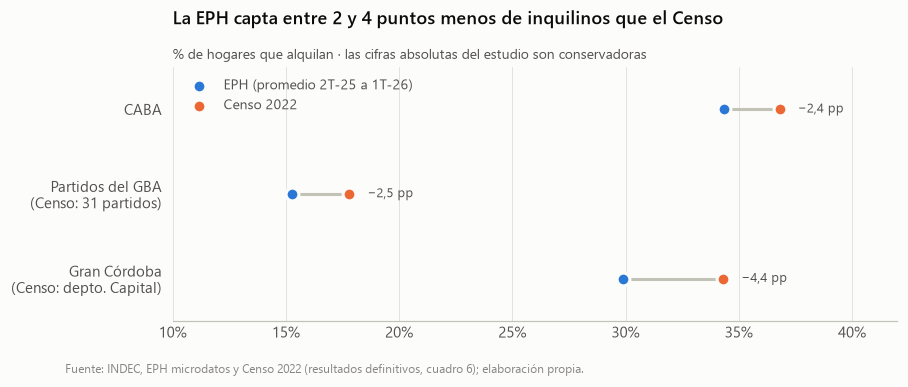

{'inquilinos_eph': np.float64(1244790.75),
 'hogares_eph_3_mercados': np.float64(6004001.5),
 'pct_inquilinos_eph': np.float64(20.733),
 'inquilinos_con_pct_censo_24p': np.float64(1416381.121),
 'inquilinos_con_pct_censo_31p': np.float64(1407878.615),
 'factor_ajuste_min': np.float64(1.091),
 'factor_ajuste_max': np.float64(1.138),
 'hogares_censo_24p': np.int64(5574450),
 'hogares_censo_31p': np.int64(5934950),
 'alquilados_censo_24p': np.int64(1358421),
 'alquilados_censo_31p': np.int64(1415167),
 'pct_propia_pais_censo': 65.666,
 'pct_alquilada_pais_censo': 20.976,
 'hogares_pais_censo': 15932302.0}

In [16]:
import validacion_censo
resumen = validacion_censo.main(verbose=False, con=con)
comp = pd.read_csv(EV / "validacion_censo" / "comparacion_eph_censo.csv")
display(comp.round(1))

d = comp[comp.geografia_censo.isin(["CABA", "31 partidos", "Depto. Capital"])].iloc[::-1]
etiquetas = {"CABA": "CABA", "Partidos del GBA": "Partidos del GBA\n(Censo: 31 partidos)", "Gran Córdoba": "Gran Córdoba\n(Censo: depto. Capital)"}
fig, ax = plt.subplots(figsize=(8.5, 3.0))
y = np.arange(len(d))
ax.hlines(y, d.pct_alquilada_eph, d.pct_alquilada_censo, color=viz.BASELINE, lw=2)
ax.scatter(d.pct_alquilada_eph, y, s=70, color=viz.BLUE, zorder=3, edgecolor=viz.SURFACE, linewidth=2, label="EPH (promedio 2T-25 a 1T-26)")
ax.scatter(d.pct_alquilada_censo, y, s=70, color=viz.ORANGE, zorder=3, edgecolor=viz.SURFACE, linewidth=2, label="Censo 2022")
for yi, r in zip(y, d.itertuples()):
    ax.text(max(r.pct_alquilada_eph, r.pct_alquilada_censo) + 0.8, yi, f"{fmt_decimal(r.dif_alquila_pp)} pp".replace("-", "−"), va="center", fontsize=8.5, color=viz.INK_2)
ax.set_yticks(y, [etiquetas[z] for z in d.zona])
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.xaxis.set_major_formatter(viz.EJE_PCT)
ax.set_xlim(10, 42); ax.set_ylim(-0.5, len(d) - 0.5)
ax.legend(loc="upper left")
ax.set_title("La EPH capta entre 2 y 4 puntos menos de inquilinos que el Censo")
viz.subtitle(ax, "% de hogares que alquilan · las cifras absolutas del estudio son conservadoras")
viz.source(fig, "INDEC, EPH microdatos y Censo 2022 (resultados definitivos, cuadro 6); elaboración propia.")
viz.save(fig, "02_eph_vs_censo")
plt.show()
{k: round(v, 3) for k, v in resumen.items()}

**Lectura:** la EPH capta algo menos de inquilinos que el Censo en los tres mercados. Si los captara igual, habría entre **1,36 y 1,42 millones de hogares inquilinos** en lugar de 1,24 millones. Por eso las cifras absolutas se informan también como un **rango ajustado al Censo** (factor 1,09 a 1,14); los porcentajes no cambian.

In [17]:
con.execute("SELECT * FROM hogares_eph LIMIT 5").df()

,hogar_id,codusu,nro_hogar,anio,trimestre,periodo,aglomerado,mercado,tenencia_cod,tenencia,miembros,ingreso_declarado,itf_nominal,itf_real_ago26,ingreso_titulares_ago26,...,jefe_situacion_laboral,tiene_conyuge,hogar_formal,perceptores_ingreso,personas_ocupadas,personas_con_mas_de_un_trabajo,trabajos_en_el_hogar,tiene_ingreso_no_laboral,jefe_o_conyuge_indep_registrado,jefe_o_conyuge_monotributo_social,hijos,otros_familiares,no_familiares,tipo_hogar,tramo_edad_jefe
0,TQSMNORYXHLOKQCDEGJBF00886496-1,TQSMNORYXHLOKQCDEGJBF00886496,1,2025,3,20253,13,Gran Córdoba,2,Propietario,4,True,"874,801.00","1,168,349.82","1,168,349.82",...,Asalariado informal,False,False,1,1,0,1.00,True,True,False,3,0,0,Monoparental,30-39
1,TQRMNORYTHKMLSCDEGJBF00868276-1,TQRMNORYTHKMLSCDEGJBF00868276,1,2025,3,20253,13,Gran Córdoba,1,Propietario,2,True,"1,356,000.00","1,811,020.29","1,811,020.29",...,Cuenta propia,True,False,2,1,0,1.00,True,False,False,0,0,0,Pareja sin hijos,65+
2,TQRMNOPWRHMNLTCDEIIAD00889791-1,TQRMNOPWRHMNLTCDEIIAD00889791,1,2025,3,20253,32,CABA,1,Propietario,2,True,"6,020,000.00","8,040,075.32","8,040,075.32",...,Cuenta propia,True,False,2,2,0,2.00,True,True,False,0,0,0,Pareja sin hijos,65+
3,TQRMNORPSHKLRQCDEIJAH00867041-1,TQRMNORPSHKLRQCDEIJAH00867041,1,2025,3,20253,33,Partidos del GBA,1,Propietario,3,True,"2,290,000.00","3,058,433.97","1,602,672.82",...,No ocupado,False,False,3,2,0,2.00,True,False,False,2,0,0,Monoparental,50-64
4,TQRMNOPPQHJKQSCDEIJAH00886356-1,TQRMNOPPQHJKQSCDEIJAH00886356,1,2025,3,20253,33,Partidos del GBA,2,Propietario,2,True,"1,916,000.00","2,558,934.27","2,558,934.27",...,Asalariado formal,False,True,1,1,0,1.00,True,False,False,1,0,0,Monoparental,40-49


In [18]:
con.close()